# 03 - Modelagem de Risco Educacional

Este notebook transforma os sinais identificados na EDA em um modelo de risco de defasagem/piora educacional para apoiar a priorização preventiva de alunos da Passos Mágicos.

A modelagem segue a lógica executiva do projeto:

problema de negócio -> target proxy -> qualidade do recorte -> features sem vazamento -> baseline -> modelo principal -> threshold -> interpretação -> score de aplicação para 2024.

O modelo não prevê evasão/retenção diretamente e não deve ser interpretado como decisão automática. Ele é uma ferramenta de triagem para apoiar a equipe pedagógica, psicossocial e psicopedagógica.

## 1) Problema de negócio

A Passos Mágicos acompanha alunos ao longo do tempo por múltiplos indicadores. O desafio do Datathon é transformar esses sinais em uma probabilidade de risco educacional, permitindo priorizar alunos que podem precisar de atenção antes de uma queda consolidada de desempenho ou aumento de defasagem.

Neste contexto, o objetivo do modelo é responder:

> Quais alunos apresentam maior probabilidade de entrar em risco de defasagem/piora educacional e quais fatores ajudam a explicar essa sinalização?

Como o foco é prevenção, `recall` da classe de risco é uma métrica central: falso negativo significa aluno em risco que o modelo não sinalizou.

In [1]:
from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    PrecisionRecallDisplay,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

gold_path = PROJECT_ROOT / "data" / "gold" / "base_modelagem_risco.csv"
silver_path = PROJECT_ROOT / "data" / "silver" / "base_unificada_validada_enriquecida.csv"
scored_path = PROJECT_ROOT / "data" / "gold" / "base_modelagem_risco_scored.csv"

ANOS_MODELAGEM = [2022, 2023]
ANO_SCORE = 2024

df = pd.read_csv(gold_path, low_memory=False)
df_silver = pd.read_csv(silver_path, low_memory=False)

print("Base Gold rotulada:", df.shape)
print("Base Silver para scoring:", df_silver.shape)
display(df.head(3))

Base Gold rotulada: (3262, 28)
Base Silver para scoring: (5490, 26)


,ra,nome,ano_referencia,fase,turma,idade,genero,ano_ingresso,instituicao_ensino,pedra,...,defasagem,matematica,portugues,ida_next,ian_next,defasagem_next,delta_ida_next,delta_ian_next,delta_defasagem_next,target_risco
0,RA-1,ALUNO-1,2021,2.0,G,NaN,NaN,NaN,Rede Decisão,Ametista,...,-1.0,NaN,NaN,4.0,5.0,-1.0,-4.8,0.0,0.0,1
1,RA-1,Aluno-1,2022,7,A,19.0,Menina,2016.0,Escola Pública,Quartzo,...,-1.0,2.7,3.5,NaN,10.0,0.0,NaN,5.0,1.0,1
2,RA-1,Aluno-1,2023,FASE 8,8E,NaN,Feminino,2016.0,Privada *Parcerias com Bolsa 100%,NaN,...,0.0,NaN,NaN,NaN,10.0,0.0,NaN,0.0,0.0,0


## 2) Target de risco e recorte modelável

O enunciado do Datathon pede um modelo para identificar alunos em risco **antes de queda no desempenho ou aumento da defasagem**. Portanto, o `target_risco` deste projeto é um **proxy de risco de defasagem/piora educacional**, não um target direto de evasão ou retenção.

O target foi construído previamente na camada Gold a partir da evolução temporal do aluno. Ele sinaliza risco quando há piora futura nos indicadores definidos pela regra de negócio, como queda de IDA, aumento de IAN conforme regra operacional adotada ou aumento de defasagem.

Para evitar vazamento de dados, colunas futuras (`*_next`) e deltas futuros (`delta_*_next`) não entram como features do modelo. Elas são usadas apenas para construir/validar o target.

Como 2024 não possui ano seguinte na base, ele **não tem target real conhecido**. Por isso, 2024 seré usado como base de aplicação do score, enquanto o treino/teste usa anos anteriores com rótulo disponível e comparável.

**Cobertura Silver -> Gold e uso de cada ano**

,ano_referencia,registros_silver,alunos_silver,registros_gold,alunos_gold,taxa_risco,pct_silver_em_gold,uso_modelagem
0,2020,622,622,229,229,0.00,36.82,diagnóstico
1,2021,1349,1349,1175,1175,22.81,87.10,diagnóstico
2,2022,1349,1349,1093,1093,43.82,81.02,treino/teste
3,2023,1014,1014,765,765,57.25,75.44,treino/teste
4,2024,1156,1156,0,0,NaN,0.00,scoring sem target


**Qualidade dos indicadores usados no target na Silver**

,ano_referencia,pct_ida_nulo,pct_ian_nulo,pct_defasagem_nulo
0,2020,100.00,100.00,100.00
1,2021,49.15,49.15,49.15
2,2022,12.90,12.90,36.25
3,2023,7.59,0.00,0.00
4,2024,8.74,0.00,0.00


**Distribuição do target no recorte modelável (2022-2023)**

,target_risco,registros,percentual
0,0,941,50.65
1,1,917,49.35


,ano_referencia,registros,alunos,taxa_risco
0,2022,1093,1093,43.82
1,2023,765,765,57.25


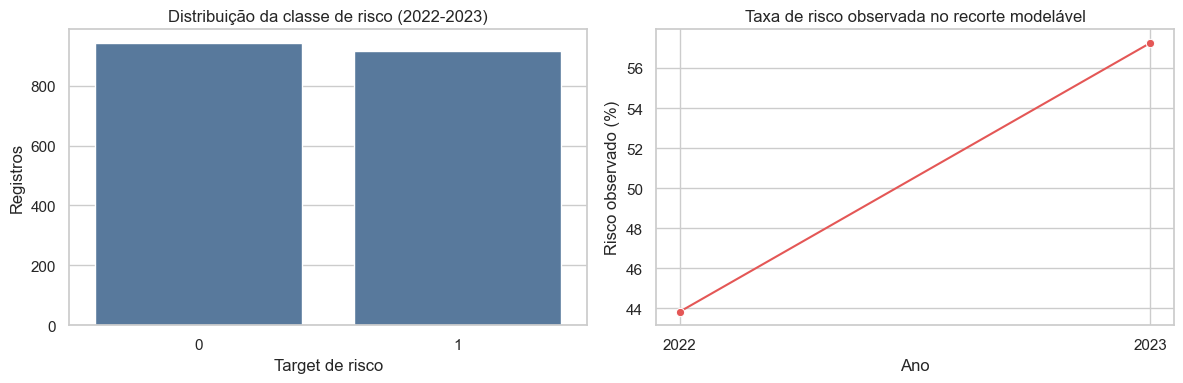

In [2]:
target_col = "target_risco"

silver_by_year = (
    df_silver.groupby("ano_referencia", as_index=False)
    .agg(registros_silver=("ra", "count"), alunos_silver=("ra", "nunique"))
)

gold_by_year = (
    df.groupby("ano_referencia", as_index=False)
    .agg(
        registros_gold=("ra", "count"),
        alunos_gold=("ra", "nunique"),
        taxa_risco=(target_col, "mean"),
    )
)
gold_by_year["taxa_risco"] = gold_by_year["taxa_risco"] * 100

coverage = silver_by_year.merge(gold_by_year, on="ano_referencia", how="left")
coverage["registros_gold"] = coverage["registros_gold"].fillna(0).astype(int)
coverage["alunos_gold"] = coverage["alunos_gold"].fillna(0).astype(int)
coverage["pct_silver_em_gold"] = coverage["registros_gold"] / coverage["registros_silver"] * 100
coverage["uso_modelagem"] = np.where(
    coverage["ano_referencia"].isin(ANOS_MODELAGEM),
    "treino/teste",
    np.where(coverage["ano_referencia"].eq(ANO_SCORE), "scoring sem target", "diagnóstico"),
)

target_quality = (
    df_silver.groupby("ano_referencia", as_index=False)
    .agg(
        pct_ida_nulo=("ida", lambda s: s.isna().mean() * 100),
        pct_ian_nulo=("ian", lambda s: s.isna().mean() * 100),
        pct_defasagem_nulo=("defasagem", lambda s: s.isna().mean() * 100),
    )
)

model_labeled = df[df["ano_referencia"].isin(ANOS_MODELAGEM)].copy()
class_dist = (
    model_labeled[target_col]
    .value_counts(dropna=False)
    .rename_axis("target_risco")
    .reset_index(name="registros")
)
class_dist["percentual"] = class_dist["registros"] / class_dist["registros"].sum() * 100

by_year_model = (
    model_labeled.groupby("ano_referencia", as_index=False)
    .agg(registros=("ra", "count"), alunos=("ra", "nunique"), taxa_risco=(target_col, "mean"))
)
by_year_model["taxa_risco"] = by_year_model["taxa_risco"] * 100

display(Markdown("**Cobertura Silver -> Gold e uso de cada ano**"))
display(coverage.round(2))

display(Markdown("**Qualidade dos indicadores usados no target na Silver**"))
display(target_quality.round(2))

display(Markdown("**Distribuição do target no recorte modelável (2022-2023)**"))
display(class_dist.round(2))
display(by_year_model.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=class_dist, x="target_risco", y="registros", ax=axes[0], color="#4c78a8")
axes[0].set_title("Distribuição da classe de risco (2022-2023)")
axes[0].set_xlabel("Target de risco")
axes[0].set_ylabel("Registros")

sns.lineplot(data=by_year_model, x="ano_referencia", y="taxa_risco", marker="o", ax=axes[1], color="#e45756")
axes[1].set_title("Taxa de risco observada no recorte modelável")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Risco observado (%)")
axes[1].set_xticks(ANOS_MODELAGEM)
plt.tight_layout()
plt.show()

**Leitura executiva:** a Gold é menor que a Silver porque o target depende de informação futura. Isso é esperado em modelagem temporal: só é possível rotular anos em que existe observação posterior. O ano de 2024 não deve ser tratado como ausência de dados; ele é a base de aplicação do score. Para reduzir distorções, o treino/teste fica concentrado em 2022-2023, anos alinhados ao enunciado e com target comparável. Essa escolha evita interpretar 2020 como risco zero artificial.

## 3) Preparação das features e prevenção de vazamento

A modelagem usa variáveis disponíveis no momento da observação. Colunas que carregam informação futura são removidas.

A variável `fase` recebe o mesmo cuidado metodológico da EDA: quando usada, ela é transformada em `fase_analitica`, separando fase/série/ciclo de turma. A coluna original `fase` não é usada diretamente como dimensão principal.

In [3]:
def normalizar_texto(valor):
    if pd.isna(valor):
        return np.nan

    texto = str(valor).strip().upper()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = re.sub(r"\s+", " ", texto)
    texto = re.sub(r"\.0$", "", texto)
    return texto


def fase_analitica(valor):
    if pd.isna(valor):
        return np.nan

    v = normalizar_texto(valor)
    v_sem_fase = re.sub(r"^FASE\s*", "", v).strip()

    if "ALFA" in v_sem_fase:
        return "ALFA"

    if re.fullmatch(r"\d+", v_sem_fase):
        return f"FASE {int(v_sem_fase)}"

    m = re.fullmatch(r"(\d+)\s*([A-Z])", v_sem_fase)
    if m:
        return f"FASE {int(m.group(1))}"

    return f"OUTROS/NAO_CLASSIFICADO - {v}"


def aplicar_fase_analitica(base: pd.DataFrame) -> pd.DataFrame:
    out = base.copy()
    out["fase_analitica"] = out["fase"].apply(fase_analitica) if "fase" in out.columns else np.nan
    return out


def ensure_feature_columns(base: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    out = base.copy()
    for col in feature_cols:
        if col not in out.columns:
            out[col] = np.nan
    return out[feature_cols].copy()


df_gold_features = aplicar_fase_analitica(df)
df_score_2024 = aplicar_fase_analitica(df_silver[df_silver["ano_referencia"].eq(ANO_SCORE)].copy())

leakage_cols = [
    "ida_next",
    "ian_next",
    "defasagem_next",
    "delta_ida_next",
    "delta_ian_next",
    "delta_defasagem_next",
]

numeric_candidates = [
    "ano_referencia",
    "idade",
    "ano_ingresso",
    "inde",
    "ian",
    "ida",
    "ieg",
    "iaa",
    "ips",
    "ipp",
    "ipv",
    "defasagem",
    "matematica",
    "portugues",
]

categorical_candidates = [
    "genero",
    "instituicao_ensino",
    "pedra",
    "fase_analitica",
]

model_df = df_gold_features[df_gold_features["ano_referencia"].isin(ANOS_MODELAGEM)].copy()
model_df = model_df.dropna(subset=[target_col]).copy()

numeric_features = [c for c in numeric_candidates if c in model_df.columns and c not in leakage_cols]
categorical_features = [c for c in categorical_candidates if c in model_df.columns and c not in leakage_cols]
feature_cols = numeric_features + categorical_features

X = ensure_feature_columns(model_df, feature_cols)
y = model_df[target_col].astype(int)

feature_audit = pd.DataFrame(
    {
        "feature": feature_cols,
        "tipo": ["numerica" if c in numeric_features else "categorica" for c in feature_cols],
        "pct_nulo_treino": [X[c].isna().mean() * 100 for c in feature_cols],
        "pct_nulo_2024": [df_score_2024[c].isna().mean() * 100 if c in df_score_2024.columns else 100 for c in feature_cols],
        "n_unicos_treino": [X[c].nunique(dropna=True) for c in feature_cols],
    }
).sort_values(["tipo", "pct_nulo_treino"], ascending=[True, False])

display(Markdown("**Features usadas no modelo**"))
display(feature_audit.round(2))

display(Markdown("**Colunas removidas para evitar vazamento temporal**"))
display(pd.DataFrame({"colunas_removidas": [c for c in leakage_cols if c in df.columns]}))

print(f"Registros no recorte modelável {ANOS_MODELAGEM}: {len(model_df)}")
print(f"Registros disponíveis para score em {ANO_SCORE}: {len(df_score_2024)}")

**Features usadas no modelo**

,feature,tipo,pct_nulo_treino,pct_nulo_2024,n_unicos_treino
14,genero,categorica,26.32,0.00,4
16,pedra,categorica,13.40,5.54,5
15,instituicao_ensino,categorica,12.76,0.09,11
17,fase_analitica,categorica,9.36,0.00,10
9,ipp,numerica,45.75,8.82,70
1,idade,numerica,42.68,0.00,18
12,matematica,numerica,13.29,9.08,128
13,portugues,numerica,13.29,9.17,128
10,ipv,numerica,13.24,8.82,678
2,ano_ingresso,numerica,9.36,0.00,8


**Colunas removidas para evitar vazamento temporal**

,colunas_removidas
0,ida_next
1,ian_next
2,defasagem_next
3,delta_ida_next
4,delta_ian_next
5,delta_defasagem_next


Registros no recorte modelável [2022, 2023]: 1858
Registros disponíveis para score em 2024: 1156


## 4) Split treino/teste

O conjunto rotulado de 2022-2023 foi dividido em treino e teste com estratificação do target, preservando a proporção de risco nas duas amostras.

Essa divisão permite comparar um baseline simples com um modelo principal. O ano de 2024 fica fora da avaliação supervisionada porque ainda não possui target real conhecido; ele seré usado apenas para aplicação do score.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

split_summary = pd.DataFrame(
    [
        {
            "amostra": "treino",
            "registros": len(y_train),
            "taxa_risco": y_train.mean() * 100,
        },
        {
            "amostra": "teste",
            "registros": len(y_test),
            "taxa_risco": y_test.mean() * 100,
        },
    ]
)
display(split_summary.round(2))

,amostra,registros,taxa_risco
0,treino,1393,49.39
1,teste,465,49.25


## 5) Baseline e modelo principal

Foram treinados dois modelos:

- `LogisticRegression`: baseline interpretável e simples.
- `RandomForestClassifier`: modelo principal, capaz de capturar relações não lineares entre indicadores.

Ambos usam tratamento de nulos e codificação de variáveis categóricas dentro de `Pipeline`, reduzindo risco de inconsistência entre treino, teste e score final.

In [5]:
numeric_preprocess_logit = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

numeric_preprocess_rf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocess_logit = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess_logit, numeric_features),
        ("cat", categorical_preprocess, categorical_features),
    ]
)

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess_rf, numeric_features),
        ("cat", categorical_preprocess, categorical_features),
    ]
)

logit_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess_logit),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
    ]
)

rf_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess_rf),
        (
            "model",
            RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=2,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=1,
            ),
        ),
    ]
)

models = {
    "LogisticRegression (baseline)": logit_pipe,
    "RandomForest (principal)": rf_pipe,
}

for model in models.values():
    model.fit(X_train, y_train)

print("Modelos treinados com sucesso.")

Modelos treinados com sucesso.


## 6) Métricas comparativas

A avaliação considera acurácia, precision, recall, F1, ROC-AUC e PR-AUC. Para este problema, `recall` e `F1` da classe de risco são mais importantes do que acurácia isolada.

- Falso negativo: aluno em risco que o modelo não sinalizou.
- Falso positivo: aluno sinalizado pelo modelo que precisa ser avaliado pela equipe.

In [6]:
def evaluate_model(name, model, X_eval, y_eval, threshold=0.5):
    proba = model.predict_proba(X_eval)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        "modelo": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_eval, pred),
        "precision_risco": precision_score(y_eval, pred, zero_division=0),
        "recall_risco": recall_score(y_eval, pred, zero_division=0),
        "f1_risco": f1_score(y_eval, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, proba),
        "pr_auc": average_precision_score(y_eval, proba),
        "alunos_sinalizados": int(pred.sum()),
    }

metrics_df = pd.DataFrame(
    [evaluate_model(name, model, X_test, y_test, threshold=0.5) for name, model in models.items()]
).set_index("modelo")

display(metrics_df.round(4))

best_model_name = "RandomForest (principal)"
best_model = models[best_model_name]
proba_logit = models["LogisticRegression (baseline)"].predict_proba(X_test)[:, 1]
proba_rf = best_model.predict_proba(X_test)[:, 1]
pred_logit = (proba_logit >= 0.5).astype(int)
pred_rf_05 = (proba_rf >= 0.5).astype(int)

for name, pred, proba in [
    ("LogisticRegression (baseline)", pred_logit, proba_logit),
    ("RandomForest (principal)", pred_rf_05, proba_rf),
]:
    display(Markdown(f"**Classification report - {name} (threshold 0.50)**"))
    report = pd.DataFrame(classification_report(y_test, pred, output_dict=True, zero_division=0)).T
    display(report.round(4))

,threshold,accuracy,precision_risco,recall_risco,f1_risco,roc_auc,pr_auc,alunos_sinalizados
modelo,,,,,,,,
LogisticRegression (baseline),0.5,0.6882,0.6909,0.6638,0.6771,0.7587,0.7412,220
RandomForest (principal),0.5,0.7312,0.7281,0.7249,0.7265,0.8015,0.7653,228


**Classification report - LogisticRegression (baseline) (threshold 0.50)**

,precision,recall,f1-score,support
0,0.6857,0.7119,0.6985,236.0000
1,0.6909,0.6638,0.6771,229.0000
accuracy,0.6882,0.6882,0.6882,0.6882
macro avg,0.6883,0.6878,0.6878,465.0000
weighted avg,0.6883,0.6882,0.6880,465.0000


**Classification report - RandomForest (principal) (threshold 0.50)**

,precision,recall,f1-score,support
0,0.7342,0.7373,0.7357,236.0000
1,0.7281,0.7249,0.7265,229.0000
accuracy,0.7312,0.7312,0.7312,0.7312
macro avg,0.7311,0.7311,0.7311,465.0000
weighted avg,0.7312,0.7312,0.7312,465.0000


**Leitura executiva:** o baseline serve como referência mínima. O RandomForest é tratado como modelo principal quando entrega melhor equilíbrio entre discriminação (`ROC-AUC`/`PR-AUC`) e capacidade de sinalizar alunos em risco (`recall`).

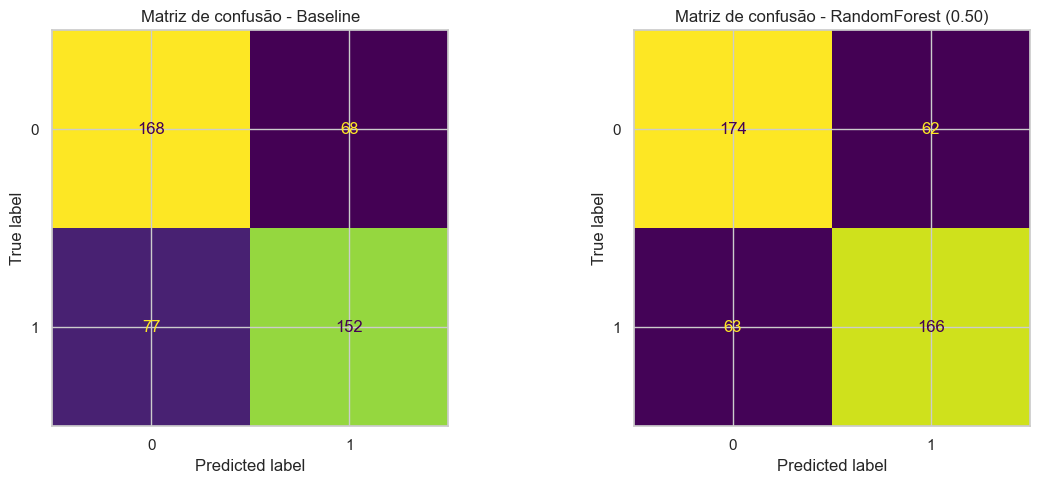

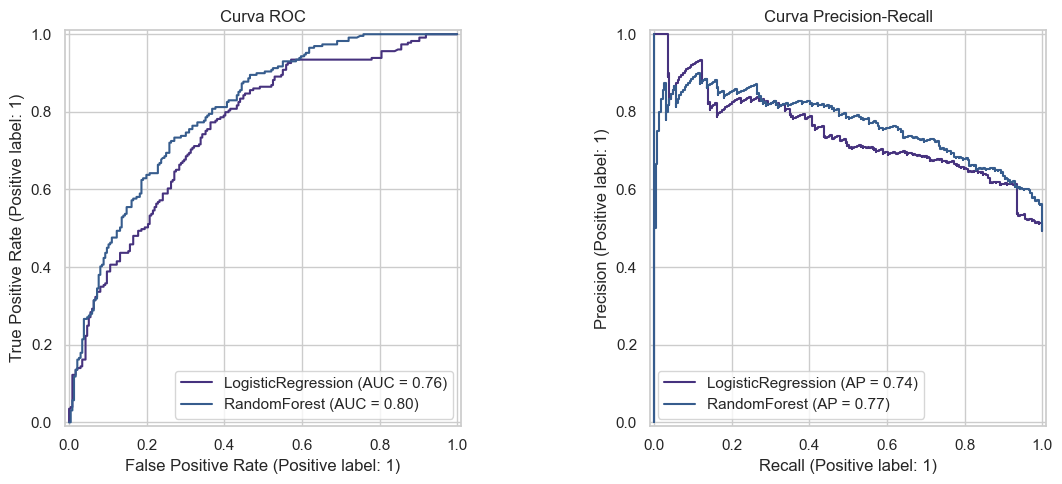

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, pred_logit)).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusão - Baseline")

ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, pred_rf_05)).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Matriz de confusão - RandomForest (0.50)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, proba_logit, name="LogisticRegression", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, proba_rf, name="RandomForest", ax=axes[0])
axes[0].set_title("Curva ROC")

PrecisionRecallDisplay.from_predictions(y_test, proba_logit, name="LogisticRegression", ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, proba_rf, name="RandomForest", ax=axes[1])
axes[1].set_title("Curva Precision-Recall")
plt.tight_layout()
plt.show()

## 7) Análise de threshold

O threshold padrão `0.50` nem sempre é o melhor para prevenção. Thresholds menores aumentam a quantidade de alunos sinalizados e tendem a elevar o `recall`, mas também podem aumentar falsos positivos.

Critério usado aqui: priorizar `recall` da classe de risco e, entre thresholds com recall operacionalmente alto, escolher o melhor `F1`.

,threshold,precision_risco,recall_risco,f1_risco,accuracy,alunos_sinalizados,falsos_negativos,falsos_positivos,verdadeiros_positivos,verdadeiros_negativos
0,0.3,0.6022,0.9520,0.7377,0.6667,362,11,144,218,92
1,0.4,0.6546,0.8690,0.7467,0.7097,304,30,105,199,131
2,0.5,0.7281,0.7249,0.7265,0.7312,228,63,62,166,174
3,0.6,0.7785,0.5371,0.6357,0.6968,158,106,35,123,201
4,0.7,0.8132,0.3231,0.4625,0.6301,91,155,17,74,219


**Threshold recomendado para triagem:** 0.40. Esse ponto sinaliza 304 alunos no teste, com recall de 86.9% e precision de 65.5% para a classe de risco.

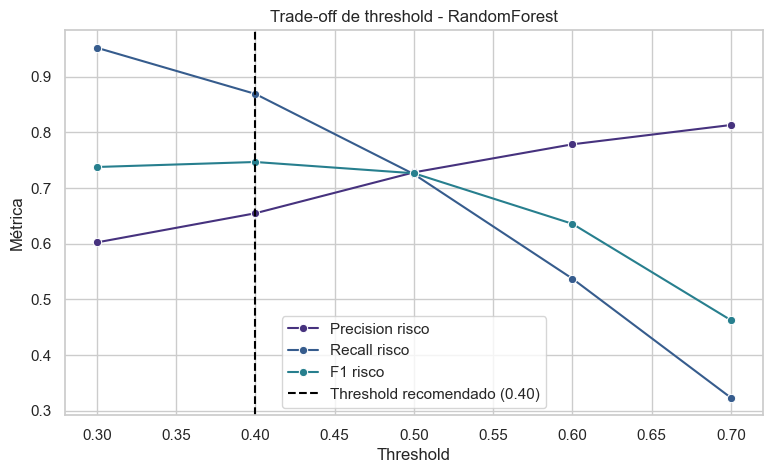

In [8]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_rows = []

for threshold in thresholds:
    pred = (proba_rf >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    threshold_rows.append(
        {
            "threshold": threshold,
            "precision_risco": precision_score(y_test, pred, zero_division=0),
            "recall_risco": recall_score(y_test, pred, zero_division=0),
            "f1_risco": f1_score(y_test, pred, zero_division=0),
            "accuracy": accuracy_score(y_test, pred),
            "alunos_sinalizados": int(pred.sum()),
            "falsos_negativos": int(fn),
            "falsos_positivos": int(fp),
            "verdadeiros_positivos": int(tp),
            "verdadeiros_negativos": int(tn),
        }
    )

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.round(4))

min_recall_operacional = 0.80
candidatos = threshold_df[threshold_df["recall_risco"] >= min_recall_operacional].copy()
if len(candidatos) > 0:
    selected_row = candidatos.sort_values(["f1_risco", "precision_risco"], ascending=False).iloc[0]
else:
    selected_row = threshold_df.sort_values("f1_risco", ascending=False).iloc[0]

selected_threshold = float(selected_row["threshold"])
display(Markdown(
    f"**Threshold recomendado para triagem:** {selected_threshold:.2f}. "
    f"Esse ponto sinaliza {int(selected_row['alunos_sinalizados'])} alunos no teste, "
    f"com recall de {selected_row['recall_risco']:.1%} e precision de {selected_row['precision_risco']:.1%} para a classe de risco."
))

plt.figure(figsize=(9, 5))
sns.lineplot(data=threshold_df, x="threshold", y="precision_risco", marker="o", label="Precision risco")
sns.lineplot(data=threshold_df, x="threshold", y="recall_risco", marker="o", label="Recall risco")
sns.lineplot(data=threshold_df, x="threshold", y="f1_risco", marker="o", label="F1 risco")
plt.axvline(selected_threshold, color="black", linestyle="--", label=f"Threshold recomendado ({selected_threshold:.2f})")
plt.title("Trade-off de threshold - RandomForest")
plt.ylabel("Métrica")
plt.xlabel("Threshold")
plt.legend()
plt.show()

**Implicação prática:** se a Passos Mágicos quiser ser mais preventiva, deve aceitar um volume maior de alunos sinalizados para reduzir falsos negativos. O threshold recomendado neste notebook é uma proposta operacional inicial e deve ser calibrado com a capacidade de atendimento da equipe.

## 8) Interpretação dos fatores do modelo

A importância de variáveis do RandomForest indica quais features foram mais relevantes para a predição. Essa leitura não representa causalidade. O termo correto é: fatores associados ao risco dentro do modelo.

,feature,importancia
0,ida,0.1164
1,ipv,0.1036
2,portugues,0.1005
3,inde,0.0887
4,matematica,0.0829
5,ieg,0.0653
6,ipp,0.0541
7,idade,0.0517
8,iaa,0.0502
9,ips,0.0389


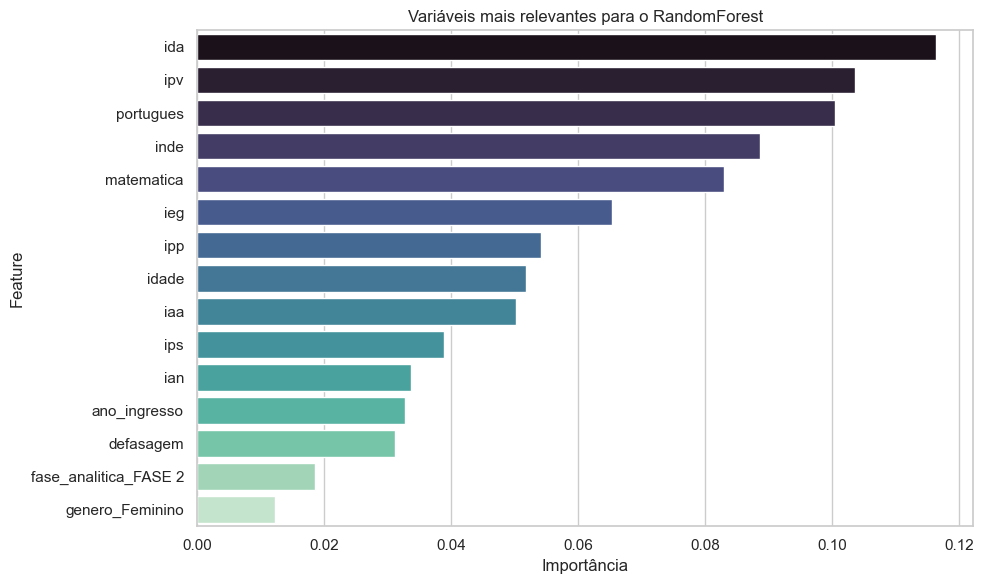

In [9]:
def get_feature_names(preprocessor):
    names = []
    if numeric_features:
        names.extend(numeric_features)
    if categorical_features:
        encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = encoder.get_feature_names_out(categorical_features).tolist()
        names.extend(cat_names)
    return names

rf_model = best_model.named_steps["model"]
feature_names = get_feature_names(best_model.named_steps["preprocess"])

importances = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "importancia": rf_model.feature_importances_,
        }
    )
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

display(importances.head(20).round(4))

plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(15), x="importancia", y="feature", palette="mako")
plt.title("Variáveis mais relevantes para o RandomForest")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Leitura executiva:** as variáveis mais importantes devem ser conectadas aos achados da EDA. Se indicadores acadêmicos, engajamento ou medidas compostas aparecem entre os fatores relevantes, isso reforça a lógica multifatorial do risco educacional.

## 9) Score de aplicação para 2024

Após avaliar o modelo, o RandomForest é treinado novamente com o recorte rotulado de 2022-2023 e aplicado aos alunos de 2024 disponíveis na Silver.

O score representa probabilidade estimada de risco de defasagem/piora educacional. Para 2024, não existe `target_risco` real conhecido dentro da base; portanto, o resultado deve ser lido como triagem preventiva, não como confirmação de risco observado.

In [10]:
final_model = Pipeline(
    steps=[
        ("preprocess", preprocess_rf),
        (
            "model",
            RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=2,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=1,
            ),
        ),
    ]
)

final_model.fit(X, y)

historical_scored = model_df.copy()
historical_X = ensure_feature_columns(historical_scored, feature_cols)
historical_scored["score_risco"] = final_model.predict_proba(historical_X)[:, 1]
historical_scored["tipo_base_score"] = "historico_rotulado_2022_2023"

score_2024 = df_score_2024.copy()
score_2024_X = ensure_feature_columns(score_2024, feature_cols)
score_2024["score_risco"] = final_model.predict_proba(score_2024_X)[:, 1]
score_2024[target_col] = np.nan
score_2024["tipo_base_score"] = "aplicacao_2024_sem_target"

for base in [historical_scored, score_2024]:
    base["threshold_modelo"] = selected_threshold
    base["pred_risco_threshold"] = (base["score_risco"] >= selected_threshold).astype(int)
    base["score_risco_pct"] = base["score_risco"] * 100

df_scored = pd.concat([historical_scored, score_2024], ignore_index=True, sort=False)
df_scored.to_csv(scored_path, index=False)

print("Arquivo com score salvo em:", scored_path)

display(Markdown(f"**Top alunos por score estimado em {ANO_SCORE}**"))
cols_top = [c for c in ["ra", "nome", "ano_referencia", "fase_analitica", "pedra", "score_risco", "pred_risco_threshold"] if c in score_2024.columns]
display(
    score_2024[cols_top]
    .sort_values("score_risco", ascending=False)
    .head(15)
    .round(4)
)

score_summary = (
    df_scored.groupby(["tipo_base_score", "ano_referencia"], dropna=False)
    .agg(
        registros=("ra", "count"),
        alunos=("ra", "nunique"),
        score_medio_pct=("score_risco_pct", "mean"),
        alunos_sinalizados=("pred_risco_threshold", "sum"),
        pct_sinalizados=("pred_risco_threshold", lambda s: s.mean() * 100),
    )
    .reset_index()
)
score_summary["threshold_modelo"] = selected_threshold
display(score_summary.round(2))

Arquivo com score salvo em: C:\Users\00157NLUC-BrenoR\Datathon\datathon_passos\data\gold\base_modelagem_risco_scored.csv


**Top alunos por score estimado em 2024**

,ra,nome,ano_referencia,fase_analitica,pedra,score_risco,pred_risco_threshold
3087,RA-438,Aluno-438,2024,FASE 2,Ametista,0.9501,1
4388,RA-753,Aluno-753,2024,FASE 1,Topázio,0.9447,1
4448,RA-767,Aluno-767,2024,FASE 1,Topázio,0.9437,1
88,RA-1018,Aluno-1018,2024,FASE 1,Ametista,0.9316,1
1670,RA-1428,Aluno-1428,2024,FASE 1,Topázio,0.9293,1
295,RA-1062,Aluno-1062,2024,FASE 1,Ametista,0.9285,1
272,RA-1058,Aluno-1058,2024,FASE 1,Ametista,0.9224,1
262,RA-1056,Aluno-1056,2024,FASE 1,Topázio,0.9189,1
4334,RA-740,Aluno-740,2024,FASE 1,Topázio,0.9184,1
4725,RA-831,Aluno-831,2024,FASE 1,Topázio,0.9170,1


,tipo_base_score,ano_referencia,registros,alunos,score_medio_pct,alunos_sinalizados,pct_sinalizados,threshold_modelo
0,aplicacao_2024_sem_target,2024,1156,1156,48.48,755,65.31,0.4
1,historico_rotulado_2022_2023,2022,1093,1093,44.03,524,47.94,0.4
2,historico_rotulado_2022_2023,2023,765,765,56.99,478,62.48,0.4


## 10) Conclusão executiva

A modelagem mostra que os sinais organizados na EDA podem ser transformados em um score operacional de risco de defasagem/piora educacional, conforme solicitado no Datathon. O RandomForest foi adotado como modelo principal por capturar relações não lineares e apresentar bom equilíbrio entre discriminação e recuperação da classe de risco.

A escolha metodológica central é separar avaliação supervisionada de aplicação operacional: 2022-2023 são usados para treino/teste porque possuem target futuro conhecido; 2024 é usado para gerar score preventivo, sem target real observado na base.

A decisão de threshold deve ser orientada pela capacidade de atendimento da Passos Mágicos: thresholds menores aumentam cobertura preventiva, enquanto thresholds maiores reduzem volume de sinalizações e tendem a elevar precision.

O próximo passo da entrega é conectar esse score ao Streamlit, garantindo que a equipe visualize probabilidade de risco, classificação conforme threshold e principais fatores associados sem interpretar o modelo como decisão automática ou como previsão direta de evasão/retenção.